In [1]:
!pip install transformers datasets scikit-learn -q

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification,
                          Trainer, TrainingArguments)
from torch.utils.data import Dataset

print(f"GPU available: {torch.cuda.is_available()}")

GPU available: True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

fake = pd.read_csv('/content/drive/MyDrive/IS6423 Group Project/Data/Fake.csv')
true = pd.read_csv('/content/drive/MyDrive/IS6423 Group Project/Data/True.csv')

fake['label'] = 0  # 0 = 假新闻
true['label'] = 1  # 1 = 真新闻

df = pd.concat([fake, true], ignore_index=True).sample(frac=1, random_state=42)
print(f"Total: {len(df)} | Fake: {(df.label==0).sum()} | Real: {(df.label==1).sum()}")

Mounted at /content/drive
Total: 44898 | Fake: 23481 | Real: 21417


In [4]:
import re

def clean_text(text):
    """简单清洗：去除多余空白、Reuters标头等"""
    text = str(text)
    text = re.sub(r'\(Reuters\)[-\s]*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_input(row, max_words=100):
    """title + 正文前 max_words 个单词，拼为一条输入"""
    title = clean_text(row['title'])
    body  = clean_text(row['text'])
    body_short = ' '.join(body.split()[:max_words])
    return title + ' [SEP] ' + body_short

df['input_text'] = df.apply(build_input, axis=1)
print(df['input_text'].iloc[0][:200])

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution [SEP] 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywoo


In [5]:
X = df['input_text'].tolist()
y = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 35918 | Val: 4490 | Test: 4490


In [6]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN    = 256

def tokenize(texts):
    return tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        enc = tokenize(texts)
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx]
        }

train_dataset = NewsDataset(X_train, y_train)
val_dataset   = NewsDataset(X_val,   y_val)
test_dataset  = NewsDataset(X_test,  y_test)

In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
# ── 9. 定义评估指标 ───────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='weighted')
    }

# ── 10. 训练参数 & Trainer ────────────────────────────────────
training_args = TrainingArguments(
    output_dir          = './results',
    num_train_epochs    = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate       = 2e-5,
    warmup_steps        = 500,
    weight_decay        = 0.01,
    eval_strategy       = 'epoch',
    save_strategy       = 'epoch',
    load_best_model_at_end = True,
    logging_dir         = './logs',
    logging_steps       = 100,
    report_to           = 'none'
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [11]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.001728,0.007553,0.998441,0.998441
2,0.005664,0.000476,0.999555,0.999555
3,0.000018,0.001067,0.999777,0.999777


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=6735, training_loss=0.023507772026716302, metrics={'train_runtime': 2573.62, 'train_samples_per_second': 41.869, 'train_steps_per_second': 2.617, 'total_flos': 7136946037389312.0, 'train_loss': 0.023507772026716302, 'epoch': 3.0})

In [13]:
# ── 12. 在测试集上最终评估 ────────────────────────────────────
results = trainer.predict(test_dataset)
preds   = np.argmax(results.predictions, axis=1)
labels  = results.label_ids

print("\n========== 最终评估结果 ==========")
print(f"Accuracy : {accuracy_score(labels, preds):.4f}")
print(f"F1 Score : {f1_score(labels, preds, average='weighted'):.4f}")
print("\n分类报告:")
print(classification_report(labels, preds, target_names=['Fake', 'Real']))


========== 最终评估结果 ==========
Accuracy : 0.9987
F1 Score : 0.9987

分类报告:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2348
        Real       1.00      1.00      1.00      2142

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



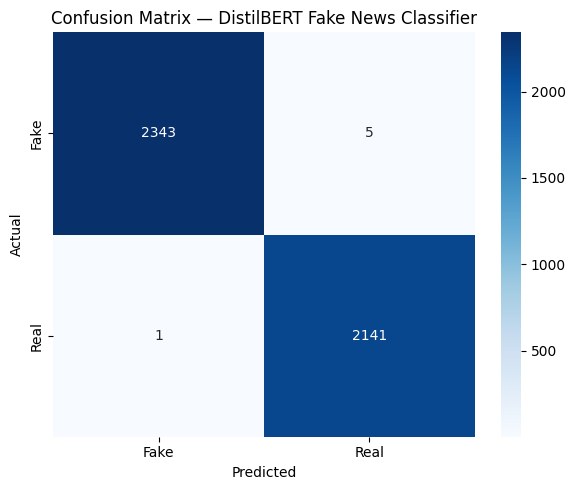

In [14]:
# ── 13. 混淆矩阵可视化 ────────────────────────────────────────
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — DistilBERT Fake News Classifier')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [16]:
model.save_pretrained('./fake_news_distilbert')
tokenizer.save_pretrained('./fake_news_distilbert')
print("模型已保存至 ./fake_news_distilbert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

模型已保存至 ./fake_news_distilbert
